# Esame di Metodi Numerici - 6 Luglio 2023
## Turno II -- Ore 11.45

## Esercizio 1


Nel file ``Test_II.mat`` sono memorizzate le matrici A1, A2 ed A3 ed i vettori b1,b2,b3. Risolvere i 3 sistemi lineari aventi ciascuno di essi come matrice dei coefficienti A1 e termine noto b1, A2 e termine noto b2, A3 e terimine noto b3  utilizzando il metodo più adatto per ciascuno di essi e  commentare i risultati ottenuti  giustificandoli alla luce della teoria.
Verificare se le matrici sono malcondizionate, dire teoricamente cosa questo implica e verificarlo sperimentalmente.


Per la lettura dei dati procedere nel seguente modo:

``from scipy.io import loadmat``

``import numpy as np``

``dati = loadmat('Test_II.mat')``

``A1=dati["A1"] ``

``A1=A1.astype(float)``

`` b1=dati["b1"] ``

`` b1=b1.astype(float)``

``A2=dati["A2"] ``

``A2=A2.astype(float)``

`` b2=dati["b2"] ``

`` b2=b2.astype(float)``

``A3=dati["A3"] ``

``A3=A3.astype(float)``

`` b3=dati["b3"] ``

`` b3=b3.astype(float)``



                                                                    Punti 16

A2: Cond di G 100.00000000000021
jacobi RAGGIO SPETTRALE 0.08830920241884369
seidel RAGGIO SPETTRALE 0.02475007827673617


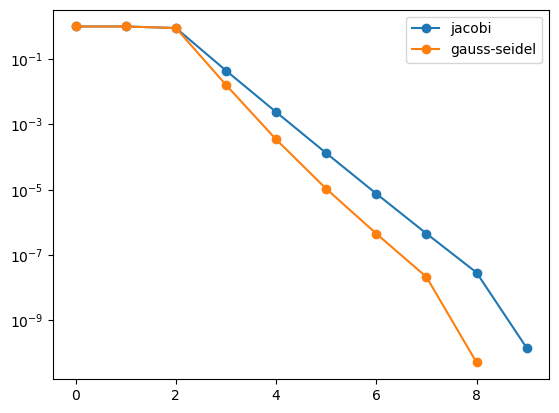

In [79]:
from scipy.io import loadmat
import numpy as np
import numpy.linalg as lin
from numpy.linalg import matrix_rank as rank
from numpy.linalg import norm 
import matplotlib.pyplot as plt
import scipy as sp
import scipy.linalg as splin
from SolveTriangular import *
from itertools import takewhile

dati = loadmat('Test_II.mat')
A1=dati["A1"]
A1=A1.astype(float)
b1=dati["b1"].ravel()
b1=b1.astype(float)
A2=dati["A2"]
A2=A2.astype(float)
b2=dati["b2"].ravel()
b2=b2.astype(float)
A3=dati["A3"]
A3=A3.astype(float)
b3=dati["b3"].ravel()
b3=b3.astype(float)

#abbiamo usato qr 
Q, R = splin.qr(A1)
x = Usolve(R, Q.T @ b1)

#assicuriamoci che la nostra matrice abbia rango massimo
assert(rank(A2) == A2.shape[1])

#Poiche il condizionamente è mediamente grande possiamo utilizzare il metodo delle equazioni normali 
#ai minimi quadrati
def eqnorm(A, b):
    G = A.T @ A
    print(f"A2: Cond di G {lin.cond(G)}")
    L = splin.cholesky(G)
    return Usolve(L, Lsolve(L, A.T @ b))

x2 = eqnorm(A2, b2)

#matrice grande e strettamente dominante
#E definita positiva ma non simmetrica
#possiamo usare uno dei metodi diretti
assert(all(lin.eigvals(A3) > 0))

def iterate(func, start):
    while True:
        yield start
        start = func(*start)

def direct(A, b, new, M, N, name, x0=None, toll=1e-8, itmax=1000):

    err = lambda x, px: norm(x-px)/norm(x)
    
    if x0 is None:
        x0 = np.zeros_like(b) + 0.1

    spectrum = np.max(np.abs(lin.eigvals(splin.inv(M) @ N)))
    print(f"{name} RAGGIO SPETTRALE {spectrum}")
    if spectrum >= 1:
        print("Soluzione non converge")
    
    stop_criteria = lambda i, args: i < itmax and args[1] >= toll

    def passo(x, errx, prev):
        return new(x), err(x, prev), x
        
    iter = iterate(passo, (x0, 1, 0)) 
    arr = list(dict(takewhile(lambda param: stop_criteria(*param), enumerate(iter))).values()) \
        + [next(iter)]
    
    return arr[-1][0], len(arr), [er for _, er, _ in arr]

def gauss_seidel(A, b):
    F = np.triu(A,1)
    M = A - F
    return direct(A, b, lambda x: Lsolve(M, (b - (F @ x))), M, -F, 'seidel')

def jacobi(A, b):
    D = np.diag(A)
    M = np.diagflat(D)
    N = A - M
    return direct(A, b, lambda x: (b - (N @ x)) / D, M, N, 'jacobi')

_, it, err = jacobi(A3, b3)
_, it1, err1 = gauss_seidel(A3, b3)
plt.semilogy(range(it), err, "-o", label='jacobi')
plt.semilogy(range(it1), err1, "-o", label='gauss-seidel')
plt.legend()
plt.show()

# Esercizio 2

Data l'equazione di 2° grado $$\frac{1}{2} x^2+2bx-c=0$$

con $b=10^7, c=10^{-i},i=-5,\cdots,12 $

- a) Scrivere le due formule algebriche per ricavare i valori delle 2 soluzioni

                                                                                    1 punto
- b) Studiare l'indice di condizionamento delle 2 formule algebriche, facendo uso del risultato teorico visto a lezione riguardo l'indice di condizionamento della valutazione di una funzione. (Spiegare il significato di problema mal condizionato) e dire quale delle due formule è malcondizionata. Per quali valori di $c$ il problema risulta ben condizionato?

                                                                                    5 punti

- c) Nel caso in cui una delle due formule risulti mal condizionata, proporre una soluzione algebricamente equivalente che non sia malcondizionata.

                                                                                    3 punti

                                                                        Totale 9 punti

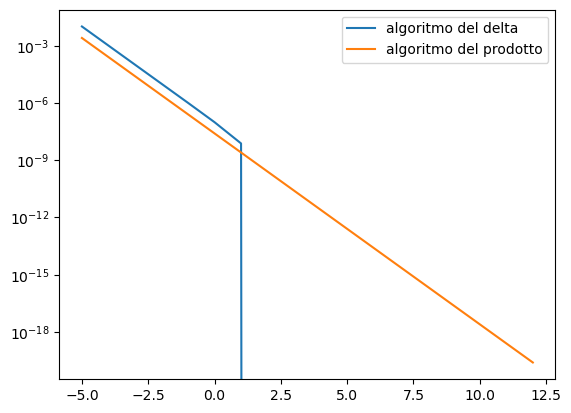

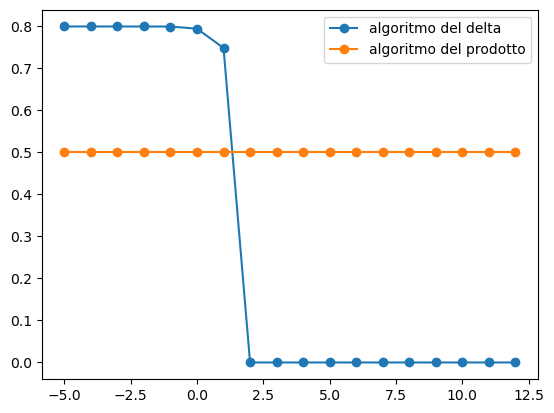

In [34]:
import numpy as np
from numpy.linalg import norm 
import matplotlib.pyplot as plt

i = np.arange(-5, 13)
a = 1/2
b = 2*10**7
c = -(10.**-i)

delta = lambda a, b, c: np.sqrt(b**2 - 4*(a)*(c))
def delta_solve(a, b, c):
    return (-b+delta(a, b, c))/a, (-b-delta(a, b, c))/a

def prod_solve(a, b, c):
    x2 = delta_solve(a, b, c)[1]
    return c / a / x2, x2


method = ('algoritmo del delta', 'algoritmo del prodotto')
x1_del, x2 = delta_solve(a, b, c)

plt.semilogy(i, x1_del, label=method[0])

x1_pr, x2 = prod_solve(a, b, c)
plt.semilogy(i, x1_pr, label=method[1])
plt.legend()
plt.show()

args = a, b, c
d = lambda x, a, b, c: x + 2*b
f = lambda x, a, b, c: 1/2*a*x**2 + 2*b*x - c
K = lambda x: d(x, *args)*x/f(x, *args)

plt.plot(i, K(x1_del), 'o-', label=method[0])
plt.plot(i, K(x1_pr), 'o-',label=method[1])
plt.legend()
plt.show()


## Domanda intelligenza artificiale

 Limiti delle reti MLP (multilayer Perceptron) ed introduzione delle Reti neurali Convoluzionali. 
- Architettura di una rete neurale convoluzionale: strati convoluzionali, attivazione non lineare e pooling + parte fully connected.
- Loss function per il task della regressione.  Training di una rete. 
- Cenni sull'algoritmo di backpropagation per il calcolo delle derivate parziale della funzione costo rispetto ai pesi ditutti i layer .
- Tecniche di Ottimizzazione: metodo di discesa del gradient batch, metodo del gradiente stocastico (SGD) ,metodo del gradiente stocastico minibatch.
                                                                                [7  punti]
